# Diabetes AdaBoost 회귀

## 개요
- AdaBoost Regressor를 활용한 당뇨병 진행도 예측
- 순차적 앙상블: 큰 오차 샘플에 집중
- GridSearchCV로 최적화

## AdaBoost 회귀 특징
- 예측 오차가 큰 샘플에 가중치 부여
- 약한 학습기 순차적 조합
- 손실 함수로 가중치 조정
- 복잡한 비선형 패턴 학습

## 주요 단계
1. 데이터 로드 및 분리
2. AdaBoost Regressor 설정
3. GridSearchCV 최적화
4. 회귀 성능 평가 및 피처 중요도

## 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

## 1. 데이터 로드

**Diabetes 데이터셋**
- 442개 샘플, 10개 피처
- 당뇨병 진행도 예측 (회귀 문제)

In [2]:
# 데이터 로드
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

print(f"데이터 크기: {X.shape}")
print(f"피처 목록: {list(diabetes.feature_names)}")
print(f"\n타겟 통계:")
print(f"  평균: {y.mean():.2f}")
print(f"  범위: {y.min():.0f} ~ {y.max():.0f}")

데이터 크기: (442, 10)
피처 목록: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

타겟 통계:
  평균: 152.13
  범위: 25 ~ 346


**데이터 샘플 확인**

In [3]:
# 데이터 샘플
print("\n데이터 샘플:")
print(X.head())

print("\n기술 통계:")
print(X.describe())


데이터 샘플:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  

기술 통계:
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072

**학습/테스트 데이터 분리**

In [4]:
# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (353, 10), Test: (89, 10)


## 2. AdaBoost Regressor

**AdaBoost 회귀 작동 원리**
1. 첫 번째 약한 회귀기 학습
2. 예측 오차가 큰 샘플에 가중치 증가
3. 다음 회귀기는 높은 가중치 샘플에 집중
4. 반복하여 최종 강한 회귀기 생성

**특징**
- 순차적 학습: 이전 오차 보완
- 약한 학습기: max_depth=3 (회귀는 stump보다 깊음)
- 손실 함수: linear, square, exponential
- 비선형 패턴 학습

**하이퍼파라미터**
- n_estimators: 약한 학습기 개수
- learning_rate: 각 학습기 기여도
- loss: 가중치 업데이트 방식

**모델 설정**

In [5]:
# AdaBoost Regressor
# estimator: max_depth=3인 Decision Tree
ada_reg = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=3),
    random_state=42
)

print("AdaBoost Regressor 생성")
print(f"Base Estimator: DecisionTreeRegressor(max_depth=3)")

AdaBoost Regressor 생성
Base Estimator: DecisionTreeRegressor(max_depth=3)


## 3. GridSearchCV 하이퍼파라미터 탐색

**파라미터 그리드**
- n_estimators: [50, 100, 200]
- learning_rate: [0.01, 0.1, 1.0]
- loss: [linear, square, exponential]

**loss 함수 의미**
- linear: 선형 손실 (기본)
- square: 제곱 손실 (큰 오차 강조)
- exponential: 지수 손실 (매우 큰 오차 집중)

In [6]:
# 하이퍼파라미터 그리드
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0],
    'loss': ['linear', 'square', 'exponential']
}

print("파라미터 그리드:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

total_combinations = 1
for values in param_grid.values():
    total_combinations *= len(values)
print(f"\n총 조합 수: {total_combinations}개")

파라미터 그리드:
  n_estimators: [50, 100, 200]
  learning_rate: [0.01, 0.1, 1.0]
  loss: ['linear', 'square', 'exponential']

총 조합 수: 27개


In [7]:
# GridSearchCV
print("\nTuning AdaBoost Regressor...")
print("(교차검증 수행 중...)\n")

grid_reg = GridSearchCV(
    ada_reg,
    param_grid,
    cv=KFold(5, shuffle=True, random_state=42),
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_reg.fit(X_train, y_train)
print("\nGridSearchCV 완료!")


Tuning AdaBoost Regressor...
(교차검증 수행 중...)

Fitting 5 folds for each of 27 candidates, totalling 135 fits

GridSearchCV 완료!


## 4. 최적화 결과 분석

**최적 모델 정보**

In [8]:
# 최적 모델 추출
best_reg = grid_reg.best_estimator_

print("[최적화 결과]")
print(f"Best R2 Score (Train CV): {grid_reg.best_score_:.4f}")
print(f"\nBest Parameters:")
for param, value in grid_reg.best_params_.items():
    print(f"  {param}: {value}")

[최적화 결과]
Best R2 Score (Train CV): 0.4413

Best Parameters:
  learning_rate: 0.1
  loss: square
  n_estimators: 200


**GridSearchCV 상위 결과**

In [9]:
# 상위 5개 결과
cv_results = pd.DataFrame(grid_reg.cv_results_)
top_results = cv_results.nlargest(5, 'mean_test_score')[[
    'param_n_estimators',
    'param_learning_rate',
    'param_loss',
    'mean_test_score',
    'std_test_score'
]]

print("\n상위 5개 파라미터 조합:")
print(top_results.to_string(index=False))


상위 5개 파라미터 조합:
 param_n_estimators  param_learning_rate  param_loss  mean_test_score  std_test_score
                200                  0.1      square         0.441334        0.036370
                200                  0.1 exponential         0.437584        0.030868
                 50                  1.0 exponential         0.435967        0.023558
                200                  1.0 exponential         0.434748        0.040076
                100                  0.1      square         0.434720        0.042632


## 5. 테스트 데이터 평가

**회귀 성능 평가**

In [10]:
# 테스트 데이터 예측
y_pred = best_reg.predict(X_test)

# 평가 지표
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = np.mean(np.abs(y_test - y_pred))

print("\n[테스트 성능]")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R2 Score: {r2:.4f}")
print(f"Test MAE: {mae:.4f}")


[테스트 성능]
Test RMSE: 53.0491
Test R2 Score: 0.4688
Test MAE: 43.7349


**예측 결과 시각화**

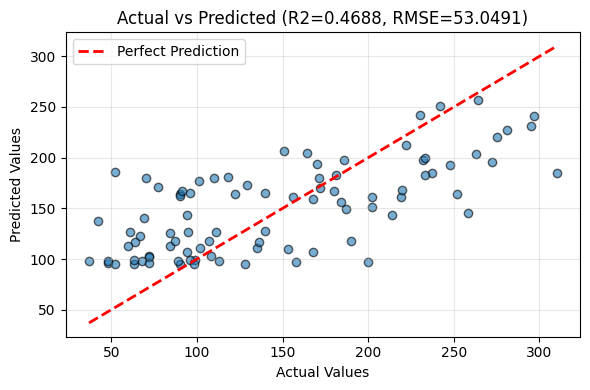

In [18]:
# 실제값 vs 예측값
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Actual vs Predicted (R2={r2:.4f}, RMSE={rmse:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 피처 중요도 분석

**AdaBoost 회귀 피처 중요도**
- 각 약한 학습기의 중요도를 가중 합산
- MSE 감소에 기여도 측정
- 높은 값: 예측에 중요한 피처

In [13]:
# 피처 중요도 추출
importances = best_reg.feature_importances_
feature_names = diabetes.feature_names
indices = np.argsort(importances)[::-1]

# 중요도 정렬
importance_df = pd.DataFrame({
    'Feature': np.array(feature_names)[indices],
    'Importance': importances[indices]
})

print("\n피처 중요도 순위:")
print(importance_df.to_string(index=False))


피처 중요도 순위:
Feature  Importance
    bmi    0.307457
     s5    0.204655
     s6    0.122535
     bp    0.105133
     s3    0.082115
    age    0.061575
     s1    0.048877
     s2    0.039130
     s4    0.020919
    sex    0.007604


**피처 중요도 시각화**

/tmp/ipython-input-2321624993.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette='viridis')


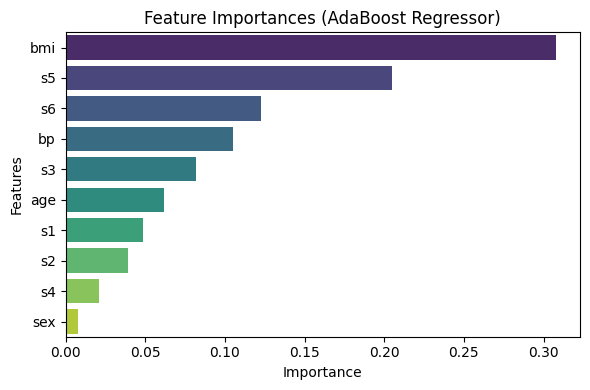

In [19]:
# 피처 중요도 시각화
plt.figure(figsize=(6, 4))
sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette='viridis')
plt.title("Feature Importances (AdaBoost Regressor)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## 8. Loss 함수별 성능 비교

**다양한 loss 함수의 영향**

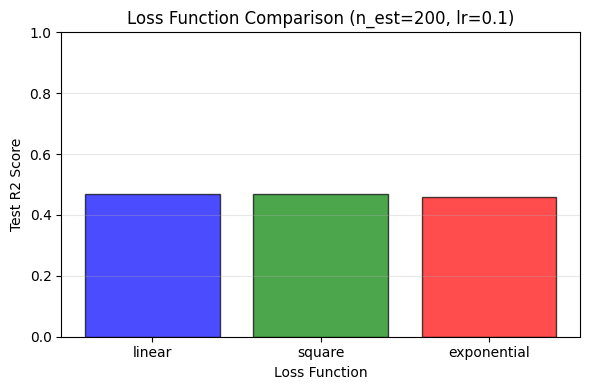


Loss 함수별 성능:
  linear: R2 = 0.4689
  square: R2 = 0.4688
  exponential: R2 = 0.4574


In [20]:
# loss 함수별 성능
loss_functions = ['linear', 'square', 'exponential']
scores = []

best_n_est = grid_reg.best_params_['n_estimators']
best_lr = grid_reg.best_params_['learning_rate']

for loss in loss_functions:
    ada = AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=3),
        n_estimators=best_n_est,
        learning_rate=best_lr,
        loss=loss,
        random_state=42
    )
    ada.fit(X_train, y_train)
    score = ada.score(X_test, y_test)
    scores.append(score)

# 시각화
plt.figure(figsize=(6, 4))
plt.bar(loss_functions, scores, color=['blue', 'green', 'red'], alpha=0.7, edgecolor='k')
plt.xlabel('Loss Function')
plt.ylabel('Test R2 Score')
plt.title(f'Loss Function Comparison (n_est={best_n_est}, lr={best_lr})')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nLoss 함수별 성능:")
for loss, score in zip(loss_functions, scores):
    print(f"  {loss}: R2 = {score:.4f}")

## 9. 기본 파라미터 vs 최적 파라미터

**GridSearch 효과 검증**

In [17]:
# 기본 파라미터로 학습
ada_default = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=3),
    random_state=42
)
ada_default.fit(X_train, y_train)
y_pred_default = ada_default.predict(X_test)

rmse_default = np.sqrt(mean_squared_error(y_test, y_pred_default))
r2_default = r2_score(y_test, y_pred_default)

# 비교
print("\nGridSearch 효과:")
print(f"기본 파라미터:")
print(f"  RMSE = {rmse_default:.4f}, R2 = {r2_default:.4f}")
print(f"\n최적 파라미터:")
print(f"  RMSE = {rmse:.4f}, R2 = {r2:.4f}")
print(f"\nRMSE 개선: {rmse_default - rmse:+.4f}")
print(f"R2 개선: {r2 - r2_default:+.4f}")


GridSearch 효과:
기본 파라미터:
  RMSE = 54.9487, R2 = 0.4301

최적 파라미터:
  RMSE = 53.0491, R2 = 0.4688

RMSE 개선: +1.8997
R2 개선: +0.0387
